## Hackathon EDA
Nombres
- Catalina González
- Amelia Díaz
- Monserrat Zúñiga
- Benjamín Cádiz

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.max_open_warning': 0})


In [2]:

df = pd.read_csv('hwc.csv')

# Selección de columnas
cols_termicas = [
    'P_NAME', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TEMP_SURF', 'P_SEMI_MAJOR_AXIS',
    'S_LUMINOSITY', 'S_TEMPERATURE', 'S_TYPE_TEMP', 'P_DISTANCE_EFF',
    'P_HABZONE_OPT', 'P_HABZONE_CON', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX',
    'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'P_ESI', 'P_HABITABLE'
]

cols_presentes = [col for col in cols_termicas if col in df.columns]
df_termico = df[cols_presentes].copy()

print("--- 1. DESCRIPCIÓN DEL DATASET (VARIABLES TÉRMICAS) ---")
print(f"Planetas totales en el catálogo: {df_termico.shape[0]}")
print("\nValores nulos en variables clave:")
print(df_termico[['P_FLUX', 'P_TEMP_EQUIL', 'P_SEMI_MAJOR_AXIS', 'S_LUMINOSITY', 'P_HABZONE_CON']].isnull().sum())

# Limpieza: Excluir planetas sin datos críticos de flujo, temperatura o distancia
df_clean = df_termico.dropna(subset=['P_TEMP_EQUIL', 'P_FLUX', 'P_SEMI_MAJOR_AXIS', 'P_ESI']).copy()

# Diferencia de flujo respecto al de la Tierra
df_clean['FLUX_DIFF_EARTH'] = abs(df_clean['P_FLUX'] - 1)


--- 1. DESCRIPCIÓN DEL DATASET (VARIABLES TÉRMICAS) ---
Planetas totales en el catálogo: 5599

Valores nulos en variables clave:
P_FLUX               234
P_TEMP_EQUIL         234
P_SEMI_MAJOR_AXIS      4
S_LUMINOSITY         233
P_HABZONE_CON          0
dtype: int64



--- 2. GENERANDO VISUALIZACIONES ---


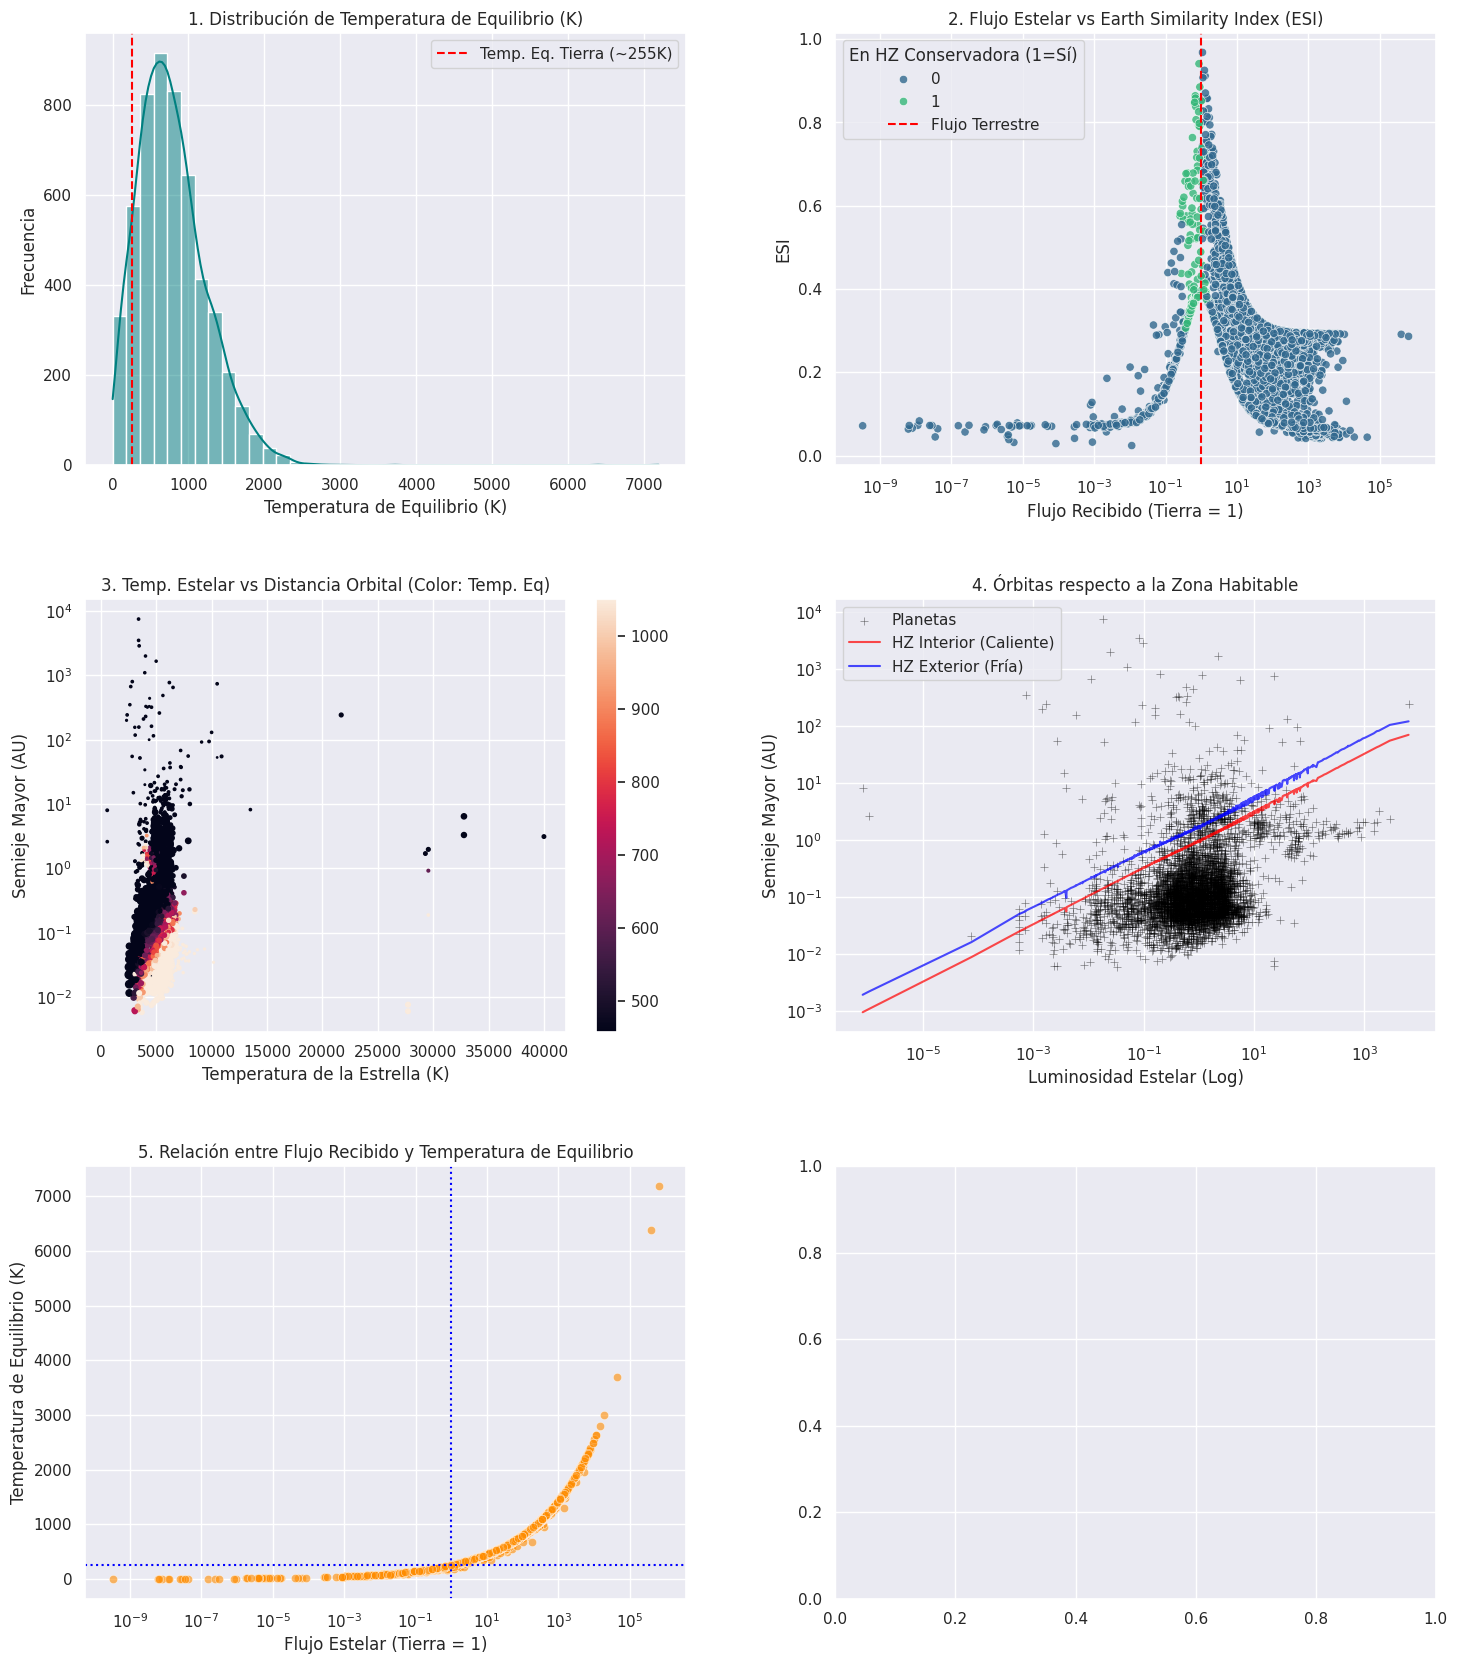

In [3]:
# Plots
print("\n--- 2. GENERANDO VISUALIZACIONES ---")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.tight_layout(pad=6.0)

# 1. Distribución de la Temperatura de Equilibrio
sns.histplot(df_clean['P_TEMP_EQUIL'], bins=40, color='teal', kde=True, ax=axes[0, 0])
axes[0, 0].axvline(x=255, color='red', linestyle='--', label='Temp. Eq. Tierra (~255K)')
axes[0, 0].set_title('1. Distribución de Temperatura de Equilibrio (K)')
axes[0, 0].set_xlabel('Temperatura de Equilibrio (K)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# 2. Flujo vs Índice de Similitud (ESI)
sns.scatterplot(data=df_clean, x='P_FLUX', y='P_ESI', hue='P_HABZONE_CON', palette='viridis', alpha=0.8, ax=axes[0, 1])
axes[0, 1].set_title('2. Flujo Estelar vs Earth Similarity Index (ESI)')
axes[0, 1].set_xlabel('Flujo Recibido (Tierra = 1)')
axes[0, 1].set_ylabel('ESI')
axes[0, 1].set_xscale('log')
axes[0, 1].axvline(x=1, color='red', linestyle='--', label='Flujo Terrestre')
axes[0, 1].legend(title='En HZ Conservadora (1=Sí)')

# 3. Temperatura de la Estrella vs Distancia Semi-Mayor
q1 = df_clean['P_TEMP_EQUIL'].quantile(0.25)
q3 = df_clean['P_TEMP_EQUIL'].quantile(0.75)

#sns.scatterplot(data=df_clean, x='S_TEMPERATURE', y='P_SEMI_MAJOR_AXIS', hue='P_TEMP_EQUIL', palette='coolwarm', size='P_ESI', sizes=(20, 200), ax=axes[1, 0])
sc =axes[1,0].scatter(df_clean["S_TEMPERATURE"], df_clean["P_SEMI_MAJOR_AXIS"], c=df_clean["P_TEMP_EQUIL"], s=df_clean["P_ESI"]/ df_clean["P_ESI"].mean() * 10, vmin=q1, vmax=q3)
cbar = plt.colorbar(sc, ax=axes[1,0])
axes[1, 0].set_title('3. Temp. Estelar vs Distancia Orbital (Color: Temp. Eq)')
axes[1, 0].set_xlabel('Temperatura de la Estrella (K)')
axes[1, 0].set_ylabel('Semieje Mayor (AU)')
axes[1, 0].set_yscale('log')

# 4. Límites de la Zona Habitable Conservadora vs Luminosidad
sns.scatterplot(data=df_clean, x='S_LUMINOSITY', y='P_SEMI_MAJOR_AXIS', color='black', marker='+', label='Planetas', ax=axes[1, 1], alpha=0.5)
sns.lineplot(data=df_clean, x='S_LUMINOSITY', y='S_HZ_CON_MIN', color='red', alpha=0.7, label='HZ Interior (Caliente)', ax=axes[1,1])
sns.lineplot(data=df_clean, x='S_LUMINOSITY', y='S_HZ_CON_MAX', color='blue', alpha=0.7, label='HZ Exterior (Fría)', ax=axes[1,1])
axes[1, 1].set_title('4. Órbitas respecto a la Zona Habitable')
axes[1, 1].set_xlabel('Luminosidad Estelar (Log)')
axes[1, 1].set_ylabel('Semieje Mayor (AU)')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# 5. Flujo Estelar vs Temperatura de Equilibrio
sns.scatterplot(data=df_clean, x='P_FLUX', y='P_TEMP_EQUIL', color='darkorange', alpha=0.6, ax=axes[2, 0])
axes[2, 0].set_title('5. Relación entre Flujo Recibido y Temperatura de Equilibrio')
axes[2, 0].set_xlabel('Flujo Estelar (Tierra = 1)')
axes[2, 0].set_ylabel('Temperatura de Equilibrio (K)')
axes[2, 0].set_xscale('log')
axes[2, 0].axvline(x=1, color='blue', linestyle=':')
axes[2, 0].axhline(y=255, color='blue', linestyle=':')

plt.show()


In [4]:
# ==========================================
# 3. Hipótesis Central
# ==========================================
print("\n--- 3. HIPÓTESIS CENTRAL ---")
print("""
Hipótesis: "El Flujo Estelar (P_FLUX) es un predictor térmico más robusto que el semieje mayor (P_SEMI_MAJOR_AXIS)
por sí solo, ya que normaliza la energía recibida independientemente de la luminosidad de la estrella.
Postulamos que los planetas con un flujo cercano a 1.0 (similar a la Tierra) dentro de la Zona Habitable
Conservadora tendrán temperaturas de equilibrio óptimas para el agua líquida, independientemente de su tipo estelar."
""")

# ==========================================
# 4. Identificación de Outliers Térmicos
# ==========================================
print("\n--- 4. IDENTIFICACIÓN DE OUTLIERS TÉRMICOS ---")
# Buscamos planetas que están DENTRO de la zona habitable conservadora, pero tienen temperaturas extremas
if 'P_HABZONE_CON' in df_clean.columns:
    outliers = df_clean[
        (df_clean['P_HABZONE_CON'] == 1) &
        ((df_clean['P_TEMP_EQUIL'] > 350) | (df_clean['P_TEMP_EQUIL'] < 180))
    ]
    print(f"Se encontraron {len(outliers)} anomalías: Planetas en la Zona Habitable Conservadora pero con Temperaturas de Eq. extremas.")
    print(outliers[['P_NAME', 'P_TEMP_EQUIL', 'P_FLUX', 'P_SEMI_MAJOR_AXIS', 'S_LUMINOSITY']].head())

# ==========================================
# 5. Selección de 3 Planetas Candidatos
# ==========================================
print("\n--- 5. 3 PLANETAS CANDIDATOS (ENFOQUE TÉRMICO) ---")
# Seleccionamos planetas que estén en la HZ Conservadora y minimizamos la diferencia de flujo con la Tierra
candidatos_termicos = df_clean[
    (df_clean['P_HABZONE_CON'] == 1) &
    (df_clean['P_TEMP_EQUIL'] >= 200) &
    (df_clean['P_TEMP_EQUIL'] <= 300)
].sort_values(by='FLUX_DIFF_EARTH', ascending=True) # Los que tienen flujo más cercano a 1 primero

top_3 = candidatos_termicos.head(3)
print("\nLos 3 candidatos más sólidos (Flujo más idéntico a la Tierra en la Zona Habitable):")
print(top_3[['P_NAME', 'P_FLUX', 'P_TEMP_EQUIL', 'P_ESI', 'P_SEMI_MAJOR_AXIS']])


--- 3. HIPÓTESIS CENTRAL ---

Hipótesis: "El Flujo Estelar (P_FLUX) es un predictor térmico más robusto que el semieje mayor (P_SEMI_MAJOR_AXIS)
por sí solo, ya que normaliza la energía recibida independientemente de la luminosidad de la estrella.
Postulamos que los planetas con un flujo cercano a 1.0 (similar a la Tierra) dentro de la Zona Habitable
Conservadora tendrán temperaturas de equilibrio óptimas para el agua líquida, independientemente de su tipo estelar."


--- 4. IDENTIFICACIÓN DE OUTLIERS TÉRMICOS ---
Se encontraron 0 anomalías: Planetas en la Zona Habitable Conservadora pero con Temperaturas de Eq. extremas.
Empty DataFrame
Columns: [P_NAME, P_TEMP_EQUIL, P_FLUX, P_SEMI_MAJOR_AXIS, S_LUMINOSITY]
Index: []

--- 5. 3 PLANETAS CANDIDATOS (ENFOQUE TÉRMICO) ---

Los 3 candidatos más sólidos (Flujo más idéntico a la Tierra en la Zona Habitable):
             P_NAME    P_FLUX  P_TEMP_EQUIL     P_ESI  P_SEMI_MAJOR_AXIS
1918     TOI-1736 c  1.000262     248.20713  0.397650       

In [5]:
df_clean.loc[df_clean['P_NAME'] == 'TOI-1736 c']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,S_TYPE_TEMP,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
1918,TOI-1736 c,1.000262,248.20713,NaN,1.381,1.778279,5807.0,G,1.404659,1,1,0.999016,2.351854,1.265376,2.229772,0.39765,0,0.000262


In [6]:
df_clean.loc[df_clean['P_NAME'] == 'Kepler-296 e']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,S_TYPE_TEMP,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
4839,Kepler-296 e,1.000607,249.37936,281.6348,0.169,0.026977,3740.0,M,0.171387,1,1,0.13388,0.343293,0.169579,0.325468,0.851871,1,0.000607


In [7]:
df_clean.loc[df_clean['P_NAME'] == 'Kepler-1981 b']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,S_TYPE_TEMP,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
5532,Kepler-1981 b,0.992703,254.27552,NaN,1.3292,1.75388,5874.0,G,1.3292,1,1,0.988124,2.322244,1.251579,2.201699,0.431129,0,0.007297
